# **ME630 -Assignment 2 - Question Statement 2**

**Name:** Meghaj Nandumar Barhate  
**Programme:** M.Tech. in Fluid and Thermal Sciences  
**Roll Number:** 261050047 

---

> # Problem 2

## **Plane Wall with Temperature-Dependent Thermal Conductivity**

A plane wall of thickness $L$, initially at uniform temperature $T_i$, is made of a material whose thermal conductivity varies linearly with temperature,

$$
k(T)=k_0\left[1+\beta(T-T_i)\right],
$$

while density $\rho$ and specific heat $c$ are taken as constant. At $t=0$ the face $x=0$ is suddenly raised to $T_s$ and held there; the face $x=L$ is insulated (Fig. 8). Because $k$ depends on the unknown temperature, the field equation must be kept in conservative (divergence) form:

$$
\rho c\frac{\partial T}{\partial t}
=
\frac{\partial}{\partial x}
\left[
k(T)\frac{\partial T}{\partial x}
\right],
\qquad 0\le x\le L,
$$

with

$$
T(x,0)=T_i,
$$

$$
T(0,t)=T_s \qquad (t>0),
$$

and

$$
\left.\frac{\partial T}{\partial x}\right|_{x=L}=0.
$$

---

## **Data**

$$
L=0.04\ \text{m},
$$

$$
\rho=7800\ \text{kg/m}^3,
$$

$$
c=470\ \text{J/(kg}\cdot\text{K)},
$$

$$
k_0=20\ \text{W/(m}\cdot\text{K)}
\qquad
\text{(value at }T=T_i\text{)},
$$

$$
\beta=2.5\times10^{-3}\ \text{K}^{-1},
$$

$$
T_i=25^\circ\text{C},
$$

$$
T_s=325^\circ\text{C}.
$$

---

## **Physical Configuration**

The wall occupies

$$
0\le x\le L.
$$

At $x=0$,

$$
T=T_s \qquad (t>0),
$$

while at $x=L$,

$$
\frac{\partial T}{\partial x}=0,
$$

corresponding to an insulated boundary.

The material thermal conductivity is

$$
k=k(T)=k_0\left[1+\beta(T-T_i)\right].
$$

**Fig. 8 —** Plane wall with temperature-dependent conductivity $k(T)$: face $x=0$ suddenly raised to $T_s$; face $x=L$ insulated.

---

# **Tasks**

## (a) Finite-Volume Discretization

Derive the finite-volume (conservative) discretization for variable $k(T)$: express the flux at each cell face using a suitably averaged conductivity between adjacent nodes (state whether you use the arithmetic or the harmonic mean, and why the harmonic mean is generally preferred when conductivity varies strongly), and write out the resulting explicit (FTCS) update.

---

## (b) Fully Implicit and Crank–Nicolson Schemes

For the fully implicit and Crank–Nicolson schemes, the face conductivities depend on the unknown $T^{n+1}$.

Describe and implement a **Picard (successive-substitution) iteration** at each time step:

1. Guess $T^{n+1}$ (e.g. from the previous time level).
2. Evaluate $k$ at the guessed values.
3. Solve the resulting linear tridiagonal system.
4. Update the guess.
5. Repeat to a stated tolerance, e.g.

$$
\max_i
\left|
T_i^{(m+1)}-T_i^{(m)}
\right|
<
10^{-3}\ ^\circ\text{C}.
$$

Separately, show that the explicit scheme's stability limit must be based on the **largest diffusivity**

$$
\alpha(T)=\frac{k(T)}{\rho c},
$$

expected in the domain (i.e. at $T=T_s$, not at $T_i$), and verify this numerically.

---

## (c) Numerical Solution and Validation

Solve with:

- the explicit scheme,
- the fully implicit scheme, and
- the Crank–Nicolson scheme.

Plot $T(x,t)$ at several times and the surface heat flux history

$$
q''(0,t)
=
-k(T)
\left.
\frac{\partial T}{\partial x}
\right|_{x=0}.
$$

As a built-in check, set

$$
\beta=0
$$

and confirm that your code collapses to the constant-property plane-wall problem. You may validate this limiting case against the plane-wall series already used in **Problem 4**.

---

## (d) Bonus — Kirchhoff Transformation

Apply the Kirchhoff transformation

$$
u
=
\frac{1}{k_0}
\int_{T_i}^{T}
k(T')\,dT'
$$

to recast the field equation approximately as a linear diffusion equation in $u$.

State clearly what assumption on $\rho c$ this requires.

Solve for $u(x,t)$ with the transformed boundary conditions, back-transform to recover $T(x,t)$, and compare with your direct nonlinear solution from part (c).

---

## (e) Comparison of Numerical Schemes

Compare the three schemes in terms of:

- computational cost,
- the number of Picard iterations per step needed by the implicit and Crank–Nicolson schemes, and
- accuracy.

Discuss whether Crank–Nicolson's higher time-accuracy is still worth its extra cost given that iteration is required at every step regardless of scheme.

> ## Library Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle

> ## Problem Geometry Description

Geometry is a linear 1D node array

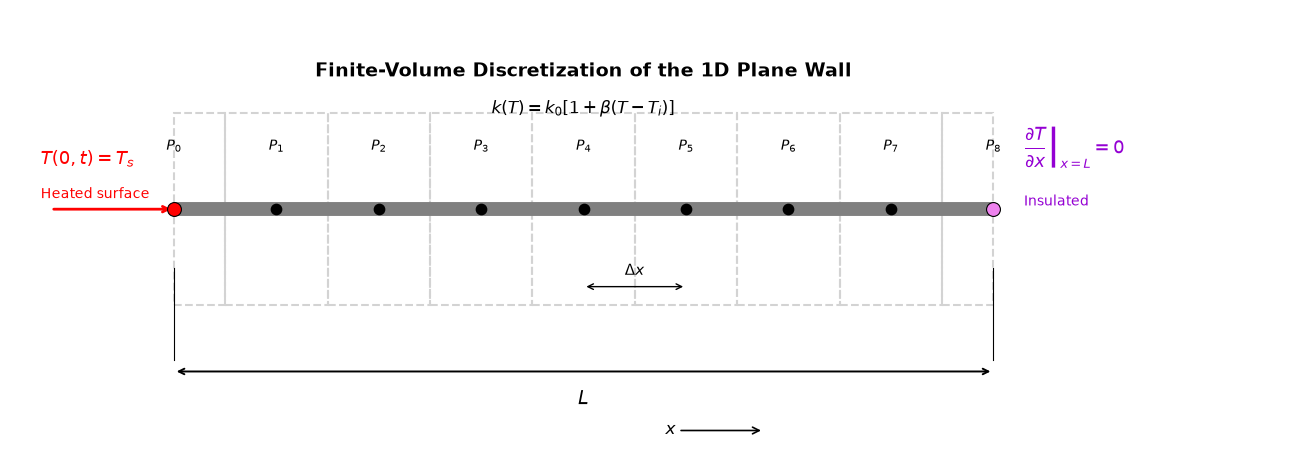

In [2]:
# ---------------------------------------------------------
# Problem / mesh parameters
# ---------------------------------------------------------
L = 0.04
N = 9
x = np.linspace(0, L, N)
dx = x[1] - x[0]

# Boundary faces are at x = 0 and x = L.
# Interior faces are halfway between neighbouring nodes.
faces = np.zeros(N + 1)

faces[0] = 0.0
faces[-1] = L
faces[1:-1] = 0.5 * (x[:-1] + x[1:])

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 4.8))

# Vertical position and thickness used only for visualization purposes as placeholders
y_rod = 0.0
rod_half_height = 0.055
cv_half_height = 0.13

ax.plot([0, L], [y_rod, y_rod], color='grey', linewidth=10, solid_capstyle='butt', zorder=2)
# Finite-volume control volumes
for i in range(N):
    x_left = faces[i]
    x_right = faces[i + 1]
    cv = Rectangle((x_left, -cv_half_height), x_right - x_left, 2 * cv_half_height, fill=False, edgecolor='lightgrey', linestyle='--', linewidth=1.5, zorder=1)
    ax.add_patch(cv)

# Nodes
ax.scatter(x[1:-1], np.zeros(N - 2), s=55, color='black', zorder=5)

# Heated boundary node: x = 0
ax.scatter(x[0], 0, s=100, color='red', edgecolor='black', linewidth=0.8, zorder=6)

# Right boundary node: x = L
ax.scatter(x[-1], 0, s=100, color='violet', edgecolor='black', linewidth=0.8, zorder=6)

for i, xi in enumerate(x):
    ax.text(xi, 0.075, rf'$P_{i}$', ha='center', va='bottom', fontsize=10)
ax.annotate('', xy=(0, 0), xytext=(-0.006, 0), arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(-0.0065, 0.055, r'$T(0,t)=T_s$', color='red', ha='left', va='bottom', fontsize=13)
ax.text(-0.0065, 0.015, 'Heated surface', color='red', ha='left', fontsize=10)

# ---------------------------------------------------------
# Insulated boundary condition at x = L
# --------------------------------------------------------
ax.text(L + 0.0015, 0.055, r'$\left.\dfrac{\partial T}{\partial x}\right|_{x=L}=0$', color='darkviolet', ha='left', va='bottom', fontsize=13)
ax.text(L + 0.0015, 0.005, 'Insulated', color='darkviolet', ha='left', fontsize=10)

y_dim = -0.22
ax.annotate('', xy=(0, y_dim), xytext=(L, y_dim), arrowprops=dict(arrowstyle='<->', color='black', lw=1.4))

# Extension lines
ax.plot([0, 0], [-0.08, y_dim + 0.015], color='black', lw=0.8)
ax.plot([L, L], [-0.08, y_dim + 0.015], color='black', lw=0.8)

ax.text(L / 2, y_dim - 0.025, r'$L$', ha='center', va='top', fontsize=14)
mid = N // 2
ax.annotate('', xy=(x[mid], -0.105), xytext=(x[mid + 1], -0.105), arrowprops=dict(arrowstyle='<->', color='black', lw=1))
ax.text(0.5 * (x[mid] + x[mid + 1]), -0.095, r'$\Delta x$', ha='center', va='bottom', fontsize=11)
ax.text(L / 2, 0.18, 'Finite-Volume Discretization of the 1D Plane Wall', ha='center', fontsize=14, fontweight='bold')
ax.text(L / 2, 0.13, r'$k(T)=k_0[1+\beta(T-T_i)]$', ha='center', fontsize=12)

# x-axis direction
ax.annotate( r'$x$', xy=(L * 0.72, -0.30), xytext=(L * 0.60, -0.30), arrowprops=dict(arrowstyle='->', color='black', lw=1.2), ha='left', va='center', fontsize=12)

ax.set_xlim(-0.008, L + 0.014)
ax.set_ylim(-0.34, 0.27)
ax.axis('off')
plt.tight_layout()
plt.show()

> ## Discretization using center node FVM

## 1. Governing Equation

The transient one-dimensional heat-conduction equation with temperature-dependent thermal conductivity is

$$
\rho c \frac{\partial T}{\partial t}
=
\frac{\partial}{\partial x}
\left(
k(T)\frac{\partial T}{\partial x}
\right),
\qquad 0\leq x\leq L
$$

where

$$
k(T)=k_0\left[1+\beta(T-T_i)\right].
$$

The initial and boundary conditions are

$$
T(x,0)=T_i,
$$

$$
T(0,t)=T_s,
\qquad t>0,
$$

and

$$
\left.
\frac{\partial T}{\partial x}
\right|_{x=L}=0.
$$

The wall is discretized using a **node-centered finite-volume method**.

---

# 2. Spatial Discretization

Let the wall be divided into $N-1$ uniform intervals with $N$ nodal points,

$$
x_i=i\Delta x,
\qquad
i=0,1,\ldots,N-1,
$$

where

$$
\Delta x=\frac{L}{N-1}.
$$

For an interior node $P$, the neighboring nodes are denoted by $W$ and $E$.

The corresponding control volume extends from the west face $w$ to the east face $e$:

$$
x_w=x_P-\frac{\Delta x}{2},
\qquad
x_e=x_P+\frac{\Delta x}{2}.
$$

Thus, for an interior control volume,

$$
V_P=A\Delta x.
$$

Since the cross-sectional area $A$ is constant, it can be cancelled from the finite-volume equations.

---

# 3. Integral Form of the Governing Equation

Integrating the governing equation over the control volume surrounding node $P$ gives

$$
\int_{x_w}^{x_e}
\rho c
\frac{\partial T}{\partial t}\,dx
=
\int_{x_w}^{x_e}
\frac{\partial}{\partial x}
\left(
k\frac{\partial T}{\partial x}
\right)\,dx.
$$

Assuming the nodal temperature represents the average temperature of the control volume,

$$
\rho c \Delta x
\frac{dT_P}{dt}
=
\left(
k\frac{\partial T}{\partial x}
\right)_e
-
\left(
k\frac{\partial T}{\partial x}
\right)_w.
$$

The temperature gradients at the faces are approximated using central differences:

$$
\left(
\frac{\partial T}{\partial x}
\right)_e
\approx
\frac{T_E-T_P}{\Delta x},
$$

and

$$
\left(
\frac{\partial T}{\partial x}
\right)_w
\approx
\frac{T_P-T_W}{\Delta x}.
$$

Therefore,

$$
\rho c \Delta x
\frac{dT_P}{dt}
=
k_e\frac{T_E-T_P}{\Delta x}
-
k_w\frac{T_P-T_W}{\Delta x}.
$$

Dividing by $\rho c\Delta x$,

$$
\boxed{
\frac{dT_P}{dt}
=
\frac{1}{\rho c\Delta x^2}
\left[
k_e(T_E-T_P)
-
k_w(T_P-T_W)
\right]
}
$$

This is the conservative finite-volume spatial discretization.

---

# 4. Temperature-Dependent Conductivity

The thermal conductivity at each node is calculated from

$$
k_P=k(T_P)
=
k_0\left[1+\beta(T_P-T_i)\right].
$$

Similarly,

$$
k_W=k_0\left[1+\beta(T_W-T_i)\right],
$$

and

$$
k_E=k_0\left[1+\beta(T_E-T_i)\right].
$$

The conductivity required in the finite-volume equation is the conductivity at the **control-volume faces**, rather than at the nodes.

---

# 5. Conductivity at the Cell Faces

For a uniform mesh, the east-face conductivity can be approximated using the arithmetic mean,

$$
k_e
=
\frac{k_P+k_E}{2},
$$

or using the harmonic mean,

$$
\boxed{
k_e
=
\frac{2k_Pk_E}{k_P+k_E}
}
$$

Similarly, at the west face,

$$
\boxed{
k_w
=
\frac{2k_Wk_P}{k_W+k_P}
}
$$

The **harmonic mean** is used here because heat transfer between adjacent nodes can be regarded as conduction through two thermal resistances in series. The harmonic mean therefore preserves the correct effective thermal resistance across the face and is generally more robust when the conductivity varies strongly between adjacent control volumes.

For the present problem,

$$
k_i
=
k_0
\left[
1+\beta(T_i-T_{\mathrm{initial}})
\right],
$$

where $T_{\mathrm{initial}}$ denotes the initial wall temperature given in the problem.

---

# 6. Explicit Finite-Volume Scheme

Using a forward difference in time,

$$
\left.
\frac{\partial T}{\partial t}
\right|_P
\approx
\frac{T_P^{n+1}-T_P^n}{\Delta t}.
$$

The finite-volume equation becomes

$$
\rho c\Delta x
\frac{T_P^{n+1}-T_P^n}{\Delta t}
=
k_e^n
\frac{T_E^n-T_P^n}{\Delta x}
-
k_w^n
\frac{T_P^n-T_W^n}{\Delta x}.
$$

Hence,

$$
\boxed{
T_P^{n+1}
=
T_P^n
+
\frac{\Delta t}{\rho c\Delta x^2}
\left[
k_e^n(T_E^n-T_P^n)
-
k_w^n(T_P^n-T_W^n)
\right]
}
$$

For node $i$,

$$
\boxed{
T_i^{n+1}
=
T_i^n
+
\frac{\Delta t}{\rho c\Delta x^2}
\left[
k_{i+\frac12}^n
(T_{i+1}^n-T_i^n)
-
k_{i-\frac12}^n
(T_i^n-T_{i-1}^n)
\right]
}
$$

for

$$
i=1,2,\ldots,N-2.
$$

The face conductivities are

$$
k_{i+\frac12}^n
=
\frac{
2k_i^n k_{i+1}^n
}{
k_i^n+k_{i+1}^n
},
$$

and

$$
k_{i-\frac12}^n
=
\frac{
2k_{i-1}^n k_i^n
}{
k_{i-1}^n+k_i^n
}.
$$

---

# 7. Left Boundary: Prescribed Temperature

At the heated surface,

$$
x=0,
$$

the temperature is prescribed directly:

$$
\boxed{
T_0^{n+1}=T_s
}
$$

for every $t>0$.

Therefore, the temperature at node $i=0$ is not obtained from the finite-volume energy equation.

For the first interior node, $i=1$,

$$
T_1^{n+1}
=
T_1^n
+
\frac{\Delta t}{\rho c\Delta x^2}
\left[
k_{\frac32}^n(T_2^n-T_1^n)
-
k_{\frac12}^n(T_1^n-T_s)
\right].
$$

---

# 8. Right Boundary: Insulated Surface

At

$$
x=L,
$$

the boundary condition is

$$
\left.
\frac{\partial T}{\partial x}
\right|_{x=L}
=0.
$$

Therefore, the conductive heat flux through the east boundary is zero:

$$
\left(
k\frac{\partial T}{\partial x}
\right)_e=0.
$$

The final node $i=N-1$ lies on the boundary, and its control volume has width

$$
\frac{\Delta x}{2}.
$$

Integrating over this half control volume gives

$$
\rho c
\frac{\Delta x}{2}
\frac{dT_{N-1}}{dt}
=
-
k_{N-\frac32}
\frac{
T_{N-1}-T_{N-2}
}{
\Delta x
}.
$$

Therefore,

$$
\boxed{
\frac{dT_{N-1}}{dt}
=
\frac{
2k_{N-\frac32}
}{
\rho c\Delta x^2
}
\left(
T_{N-2}-T_{N-1}
\right)
}
$$

and the explicit update becomes

$$
\boxed{
T_{N-1}^{n+1}
=
T_{N-1}^n
+
\frac{
2\Delta t\,k_{N-\frac32}^n
}{
\rho c\Delta x^2
}
\left(
T_{N-2}^n-T_{N-1}^n
\right)
}
$$

This equation automatically imposes zero heat flux at the insulated boundary.

---

# 9. Fully Implicit Scheme

For the fully implicit method, the complete spatial operator is evaluated at time level $n+1$:

$$
\rho c
\frac{
T_i^{n+1}-T_i^n
}{
\Delta t
}
=
\frac{1}{\Delta x^2}
\left[
k_{i+\frac12}^{n+1}
(T_{i+1}^{n+1}-T_i^{n+1})
-
k_{i-\frac12}^{n+1}
(T_i^{n+1}-T_{i-1}^{n+1})
\right].
$$

Define

$$
r_{i+\frac12}
=
\frac{
\Delta t\,k_{i+\frac12}^{n+1}
}{
\rho c\Delta x^2
},
$$

and

$$
r_{i-\frac12}
=
\frac{
\Delta t\,k_{i-\frac12}^{n+1}
}{
\rho c\Delta x^2
}.
$$

Then

$$
-r_{i-\frac12}T_{i-1}^{n+1}
+
\left(
1+r_{i-\frac12}+r_{i+\frac12}
\right)T_i^{n+1}
-
r_{i+\frac12}T_{i+1}^{n+1}
=
T_i^n.
$$

Thus,

$$
\boxed{
a_W T_{i-1}^{n+1}
+
a_P T_i^{n+1}
+
a_E T_{i+1}^{n+1}
=
b_i
}
$$

with

$$
a_W=-r_{i-\frac12},
$$

$$
a_P=1+r_{i-\frac12}+r_{i+\frac12},
$$

$$
a_E=-r_{i+\frac12},
$$

and

$$
b_i=T_i^n.
$$

The resulting coefficient matrix is tridiagonal.

---

# 10. Fully Implicit Equation at the Insulated Boundary

For the final half control volume,

$$
\rho c
\frac{\Delta x}{2}
\frac{
T_{N-1}^{n+1}-T_{N-1}^n
}{
\Delta t
}
=
-
k_{N-\frac32}^{n+1}
\frac{
T_{N-1}^{n+1}-T_{N-2}^{n+1}
}{
\Delta x
}.
$$

Define

$$
r_{N-\frac32}
=
\frac{
\Delta t\,k_{N-\frac32}^{n+1}
}{
\rho c\Delta x^2
}.
$$

Then

$$
\boxed{
-2r_{N-\frac32}T_{N-2}^{n+1}
+
\left(
1+2r_{N-\frac32}
\right)T_{N-1}^{n+1}
=
T_{N-1}^n
}
$$

---

# 11. Picard Iteration for the Nonlinear Implicit Scheme

Because

$$
k=k(T),
$$

the coefficients of the fully implicit system depend on the unknown temperatures $T^{n+1}$.

A Picard iteration is therefore performed at every time step.

Start with the initial guess

$$
T_i^{n+1,(0)}=T_i^n.
$$

At Picard iteration $m$, calculate

$$
k_i^{(m)}
=
k_0
\left[
1+\beta
\left(
T_i^{n+1,(m)}-T_{\mathrm{initial}}
\right)
\right].
$$

The face conductivity is then evaluated as

$$
k_{i+\frac12}^{(m)}
=
\frac{
2k_i^{(m)}k_{i+1}^{(m)}
}{
k_i^{(m)}+k_{i+1}^{(m)}
}.
$$

Using these conductivities, construct and solve the linear tridiagonal system

$$
A^{(m)}T^{n+1,(m+1)}=b.
$$

The iteration is continued until

$$
\boxed{
\max_i
\left|
T_i^{n+1,(m+1)}
-
T_i^{n+1,(m)}
\right|
<
10^{-3}\ ^\circ\mathrm{C}
}
$$

After convergence,

$$
T_i^{n+1}
=
T_i^{n+1,(m+1)}.
$$

---

# 12. Crank--Nicolson Scheme

The Crank--Nicolson method evaluates the diffusion operator as the average between time levels $n$ and $n+1$:

$$
\frac{
T_i^{n+1}-T_i^n
}{
\Delta t
}
=
\frac{1}{2\rho c\Delta x^2}
\left[
\mathcal{D}_i^{n+1}
+
\mathcal{D}_i^n
\right],
$$

where

$$
\mathcal{D}_i^n
=
k_{i+\frac12}^n
(T_{i+1}^n-T_i^n)
-
k_{i-\frac12}^n
(T_i^n-T_{i-1}^n).
$$

Therefore,

$$
T_i^{n+1}-T_i^n
=
\frac{\Delta t}{2\rho c\Delta x^2}
\Big[
k_{i+\frac12}^{n+1}
(T_{i+1}^{n+1}-T_i^{n+1})
-
k_{i-\frac12}^{n+1}
(T_i^{n+1}-T_{i-1}^{n+1})
$$

$$
+
k_{i+\frac12}^{n}
(T_{i+1}^{n}-T_i^{n})
-
k_{i-\frac12}^{n}
(T_i^{n}-T_{i-1}^{n})
\Big].
$$

Define

$$
r_{i+\frac12}^{n+1}
=
\frac{
\Delta t\,k_{i+\frac12}^{n+1}
}{
2\rho c\Delta x^2
},
$$

and

$$
r_{i-\frac12}^{n+1}
=
\frac{
\Delta t\,k_{i-\frac12}^{n+1}
}{
2\rho c\Delta x^2
}.
$$

The equation can then be rearranged as

$$
-r_{i-\frac12}^{n+1}T_{i-1}^{n+1}
+
\left(
1+r_{i-\frac12}^{n+1}
+r_{i+\frac12}^{n+1}
\right)T_i^{n+1}
-
r_{i+\frac12}^{n+1}T_{i+1}^{n+1}
$$

$$
=
T_i^n
+
r_{i+\frac12}^{n}
(T_{i+1}^{n}-T_i^n)
-
r_{i-\frac12}^{n}
(T_i^n-T_{i-1}^{n}).
$$

Because the $n+1$ conductivities depend on $T^{n+1}$, the Crank--Nicolson scheme also requires a Picard iteration.

---

# 13. Explicit Stability Criterion

The thermal diffusivity is

$$
\alpha(T)
=
\frac{k(T)}{\rho c}.
$$

For an explicit finite-volume scheme, the local Fourier number is

$$
Fo
=
\frac{\alpha\Delta t}{\Delta x^2}.
$$

For one-dimensional diffusion, stability requires

$$
Fo\leq\frac{1}{2}.
$$

Since the conductivity increases with temperature for $\beta>0$, the largest conductivity occurs at the highest temperature in the domain.

For this problem,

$$
T_{\max}=T_s.
$$

Therefore,

$$
k_{\max}=k(T_s).
$$

Using

$$
k(T)=k_0\left[1+\beta(T-T_i)\right],
$$

gives

$$
k_{\max}
=
20
\left[
1+
2.5\times10^{-3}(325-25)
\right].
$$

Hence,

$$
\boxed{
k_{\max}=35\ \mathrm{W/(m\cdot K)}
}
$$

and

$$
\alpha_{\max}
=
\frac{35}{7800(470)}.
$$

Thus,

$$
\boxed{
\alpha_{\max}
\approx
9.55\times10^{-6}\ \mathrm{m^2/s}
}
$$

The explicit time step should therefore satisfy

$$
\boxed{
\Delta t
\leq
\frac{\Delta x^2}{2\alpha_{\max}}
}
$$

or equivalently,

$$
\boxed{
\Delta t
\leq
\frac{\rho c\Delta x^2}{2k_{\max}}
}
$$

Since

$$
\Delta x=\frac{L}{N-1},
$$

the maximum stable time step can also be written as

$$
\boxed{
\Delta t_{\max}
=
\frac{
\rho cL^2
}{
2k_{\max}(N-1)^2
}
}
$$

For the present material properties,

$$
\boxed{
\Delta t_{\max}
\approx
\frac{83.79}{(N-1)^2}\ \mathrm{s}
}
$$

For example, if $N=9$ nodes are used,

$$
\Delta x
=
\frac{0.04}{8}
=
0.005\ \mathrm{m},
$$

and

$$
\boxed{
\Delta t_{\max}
\approx
1.31\ \mathrm{s}
}
$$

A practical explicit calculation should use a time step somewhat smaller than this limiting value.

---

# 14. Surface Heat Flux

The heat flux at the heated surface is

$$
q''(0,t)
=
-k(T)
\left.
\frac{\partial T}{\partial x}
\right|_{x=0}.
$$

Using the first two nodes,

$$
\left.
\frac{\partial T}{\partial x}
\right|_{x=0}
\approx
\frac{T_1-T_0}{\Delta x}.
$$

Since

$$
T_0=T_s,
$$

the numerical surface heat flux is

$$
\boxed{
q''(0,t)
\approx
-k(T_s)
\frac{T_1-T_s}{\Delta x}
}
$$

or equivalently,

$$
\boxed{
q''(0,t)
\approx
k(T_s)
\frac{T_s-T_1}{\Delta x}
}
$$

which is positive when heat flows from the heated surface into the wall.

---

# 15. Final Discrete Problem

The numerical problem can therefore be summarized as follows.

### Interior nodes

For

$$
i=1,\ldots,N-2,
$$

$$
\boxed{
\rho c
\frac{dT_i}{dt}
=
\frac{1}{\Delta x^2}
\left[
k_{i+\frac12}(T_{i+1}-T_i)
-
k_{i-\frac12}(T_i-T_{i-1})
\right]
}
$$

with

$$
\boxed{
k_{i+\frac12}
=
\frac{2k_i k_{i+1}}{k_i+k_{i+1}}
}
$$

and

$$
k_i
=
k_0
\left[
1+\beta(T_i-T_{\mathrm{initial}})
\right].
$$

### Heated boundary

$$
\boxed{
T_0=T_s
}
$$

### Insulated boundary

$$
\boxed{
\rho c
\frac{dT_{N-1}}{dt}
=
\frac{
2k_{N-\frac32}
}{
\Delta x^2
}
(T_{N-2}-T_{N-1})
}
$$

### Initial condition

$$
\boxed{
T_i(0)=T_{\mathrm{initial}}
}
$$

for the wall initially, followed by enforcement of

$$
T_0=T_s
$$

for $t>0$.

In [ ]:
class MeshNode:
    def __init__(self, nodeIndex, xCoordinate, westFace, eastFace, nodeType, temperature, thermalConductivity):
        self.nodeIndex = nodeIndex
        self.xCoordinate = xCoordinate
        self.westFace = westFace
        self.eastFace = eastFace
        self.controlVolumeWidth = eastFace - westFace
        self.nodeType = nodeType
        self.temperature = temperature
        self.thermalConductivity = thermalConductivity

    def UpdateTemperature(self, temperature, k0, beta, initialTemperature):
        self.temperature = temperature
        self.thermalConductivity = k0*(1 + beta*(temperature - initialTemperature))

class FiniteVolumeMesh:
    def __init__(self, length, numberOfNodes):
        self.length = length
        self.numberOfNodes = numberOfNodes
        self.deltaX = length/(numberOfNodes - 1)
        self.meshNodes = {}

def GenerateMesh(length, numberOfNodes, initialTemperature, surfaceTemperature, k0, beta):
    mesh = FiniteVolumeMesh(length, numberOfNodes)
    for nodeIndex in range(numberOfNodes):
        xCoordinate = nodeIndex*mesh.deltaX
        if nodeIndex == 0:
            westFace = 0
            eastFace = mesh.deltaX/2
            nodeType = "HeatedBoundary"
            temperature = surfaceTemperature
        elif nodeIndex == numberOfNodes - 1:
            westFace = length - mesh.deltaX/2
            eastFace = length
            nodeType = "InsulatedBoundary"
            temperature = initialTemperature
        else:
            westFace = xCoordinate - mesh.deltaX/2
            eastFace = xCoordinate + mesh.deltaX/2
            nodeType = "Interior"
            temperature = initialTemperature
        thermalConductivity = k0*(1 + beta*(temperature - initialTemperature))
        mesh.meshNodes[nodeIndex] = MeshNode(nodeIndex, xCoordinate, westFace, eastFace, nodeType, temperature, thermalConductivity)

    return mesh